# Usual Transforms in Power Systems
**Course: ELEC0447 - Analysis of Electric Power and Energy Systems**  
*Prof. Bertrand Cornélusse — University of Liège*

This interactive notebook demonstrates the fundamental mathematical transforms used in modern power system analysis, control, and protection:
1. **Fortescue Symmetrical Components ($012$)**: Unbalanced phasor decomposition into positive, negative, and zero sequence.
2. **Clarke Transform ($lphaeta0$)**: 3-phase to 2-axis stationary orthogonal frame and space vector trajectory.
3. **Park Transform ($dq0$)**: Stationary to synchronous rotating reference frame (AC to DC conversion and $2\omega$ unbalance ripple).
4. **Kron Reduction**: Network admittance matrix reduction by eliminating passive (zero-injection) buses.
5. **Full-Cycle Discrete Fourier Transform (DFT)**: Fundamental frequency phasor extraction from sampled waveforms for digital relays and PMUs.


## 0. Setup and Dependencies


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Import custom transform library
import transforms as tr

print("Transforms module successfully loaded!")


Transforms module successfully loaded!


## 1. Fortescue Symmetrical Components ($012$)

Fortescue's theorem states that any set of 3 unbalanced phasors $[\bar{V}_a, \bar{V}_b, \bar{V}_c]^T$ can be uniquely decomposed into:
* **Positive (direct) sequence ($\bar{V}_1$)**: Balanced $120^\circ$ set with $a \to b \to c$ rotation.
* **Negative (inverse) sequence ($\bar{V}_2$)**: Balanced $120^\circ$ set with reverse $a \to c \to b$ rotation.
* **Zero sequence ($\bar{V}_0$)**: Three identical in-phase phasors flowing through ground/neutral.

$$\begin{bmatrix} \bar{V}_0 \\ \bar{V}_1 \\ \bar{V}_2 \end{bmatrix} = \frac{1}{3} \begin{bmatrix} 1 & 1 & 1 \\ 1 & a & a^2 \\ 1 & a^2 & a \end{bmatrix} \begin{bmatrix} \bar{V}_a \\ \bar{V}_b \\ \bar{V}_c \end{bmatrix}, \quad a = e^{j 2\pi/3}$$


In [2]:
# Define an unbalanced 3-phase voltage set (e.g. single-phase voltage sag on phase a)
V_nominal = 230.0 # V RMS

# Phase a suffers a 50% voltage sag with a 15-degree phase jump
V_a = 0.50 * V_nominal * np.exp(1j * np.deg2rad(15.0))
V_b = 1.00 * V_nominal * np.exp(-1j * 2 * np.pi / 3)
V_c = 1.00 * V_nominal * np.exp(1j * 2 * np.pi / 3)

# Calculate Symmetrical Components
V_0, V_1, V_2 = tr.fortescue_transform(V_a, V_b, V_c)

print("Phase Voltages:")
print(f"  Va = {abs(V_a):.2f} V ∠ {np.rad2deg(np.angle(V_a)):.1f}°")
print(f"  Vb = {abs(V_b):.2f} V ∠ {np.rad2deg(np.angle(V_b)):.1f}°")
print(f"  Vc = {abs(V_c):.2f} V ∠ {np.rad2deg(np.angle(V_c)):.1f}°")

print("\nSymmetrical Components:")
print(f"  Zero Sequence (V0)     = {abs(V_0):.2f} V ∠ {np.rad2deg(np.angle(V_0)):.1f}°")
print(f"  Positive Sequence (V1) = {abs(V_1):.2f} V ∠ {np.rad2deg(np.angle(V_1)):.1f}°")
print(f"  Negative Sequence (V2) = {abs(V_2):.2f} V ∠ {np.rad2deg(np.angle(V_2)):.1f}°")

# Verification of exact reconstruction
rec_a, rec_b, rec_c = tr.inv_fortescue_transform(V_0, V_1, V_2)
assert np.allclose([rec_a, rec_b, rec_c], [V_a, V_b, V_c])
print("\n✓ Exact synthesis confirmed: inv_fortescue(V0, V1, V2) == [Va, Vb, Vc]")


Phase Voltages:
  Va = 115.00 V ∠ 15.0°
  Vb = 230.00 V ∠ -120.0°
  Vc = 230.00 V ∠ 120.0°

Symmetrical Components:
  Zero Sequence (V0)     = 40.86 V ∠ 165.9°
  Positive Sequence (V1) = 190.62 V ∠ 3.0°
  Negative Sequence (V2) = 40.86 V ∠ 165.9°

✓ Exact synthesis confirmed: inv_fortescue(V0, V1, V2) == [Va, Vb, Vc]


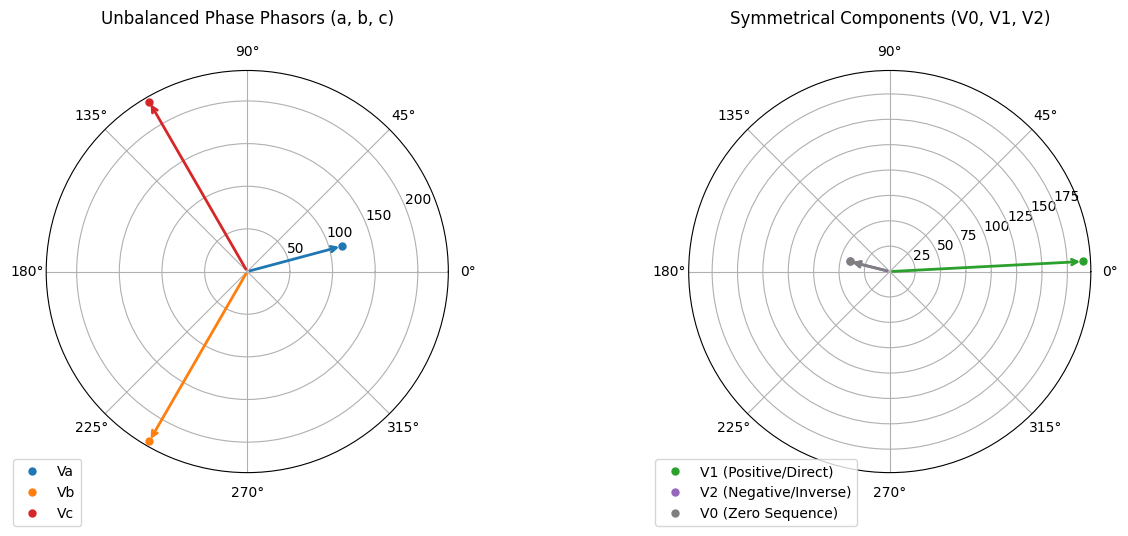

In [3]:
# Visualize Phase Phasors and Symmetrical Component Sets
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), subplot_kw={'projection': 'polar'})

def plot_phasor(ax, val, color, label, linestyle='-'):
    ax.annotate('', xy=(np.angle(val), abs(val)), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color=color, lw=2, ls=linestyle))
    ax.plot([np.angle(val)], [abs(val)], 'o', color=color, markersize=5, label=label)

# 1. Unbalanced Phase Phasors
axes[0].set_title("Unbalanced Phase Phasors (a, b, c)", pad=15)
plot_phasor(axes[0], V_a, 'tab:blue', 'Va')
plot_phasor(axes[0], V_b, 'tab:orange', 'Vb')
plot_phasor(axes[0], V_c, 'tab:red', 'Vc')
axes[0].legend(loc='lower left', bbox_to_anchor=(-0.1, -0.15))
axes[0].grid(True)

# 2. Symmetrical Components (Positive, Negative, Zero)
axes[1].set_title("Symmetrical Components (V0, V1, V2)", pad=15)
plot_phasor(axes[1], V_1, 'tab:green', 'V1 (Positive/Direct)')
plot_phasor(axes[1], V_2, 'tab:purple', 'V2 (Negative/Inverse)')
plot_phasor(axes[1], V_0, 'tab:gray', 'V0 (Zero Sequence)')
axes[1].legend(loc='lower left', bbox_to_anchor=(-0.1, -0.15))
axes[1].grid(True)

plt.tight_layout()
plt.show()


## 2. Clarke Transform ($\alpha\beta0$ Stationary Reference Frame)

The Clarke transform projects 3-phase quantities $(a, b, c)$ onto two orthogonal stationary axes $(\alpha, \beta)$ plus a homopolar component $(0)$:
$$\begin{bmatrix} v_\alpha \\ v_\beta \\ v_0 \end{bmatrix} = \frac{2}{3} \begin{bmatrix} 1 & -1/2 & -1/2 \\ 0 & \sqrt{3}/2 & -\sqrt{3}/2 \\ 1/2 & 1/2 & 1/2 \end{bmatrix} \begin{bmatrix} v_a \\ v_b \\ v_c \end{bmatrix}$$

* Under **balanced conditions**, the space vector $\vec{v}(t) = v_\alpha(t) + j v_\beta(t)$ traces a **circle of constant radius $\hat{V}$**.
* Under **unbalanced conditions**, it traces an **ellipse**.


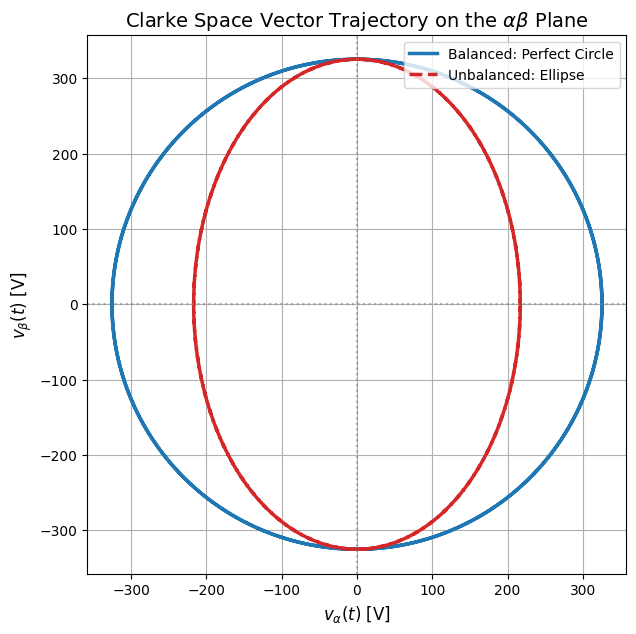

In [6]:
# Time-domain signals (50 Hz, 2 fundamental cycles)
f0 = 50.0
t = np.linspace(0, 0.04, 500)
w = 2 * np.pi * f0

# 1. Balanced 3-phase voltages
va_bal = 230 * np.sqrt(2) * np.cos(w * t)
vb_bal = 230 * np.sqrt(2) * np.cos(w * t - 2 * np.pi / 3)
vc_bal = 230 * np.sqrt(2) * np.cos(w * t + 2 * np.pi / 3)

valpha_bal, vbeta_bal, v0_bal = tr.clarke_transform(va_bal, vb_bal, vc_bal)

# 2. Unbalanced 3-phase voltages (Phase a sag by 50%)
va_unb = 0.50 * 230 * np.sqrt(2) * np.cos(w * t)
vb_unb = vb_bal
vc_unb = vc_bal

valpha_unb, vbeta_unb, v0_unb = tr.clarke_transform(va_unb, vb_unb, vc_unb)

# Plot Space Vector Trajectories on the (alpha, beta) plane
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(valpha_bal, vbeta_bal, 'tab:blue', lw=2.5, label='Balanced: Perfect Circle')
ax.plot(valpha_unb, vbeta_unb, 'tab:red', lw=2.5, linestyle='--', label='Unbalanced: Ellipse')
ax.axhline(0, color='gray', linestyle=':', alpha=0.6)
ax.axvline(0, color='gray', linestyle=':', alpha=0.6)
ax.set_aspect('equal')
ax.set_xlabel(r'$v_\alpha(t)$ [V]', fontsize=12)
ax.set_ylabel(r'$v_\beta(t)$ [V]', fontsize=12)
ax.set_title(r'Clarke Space Vector Trajectory on the $\alpha \beta$ Plane', fontsize=14)
ax.grid(True)
ax.legend(loc='upper right')
plt.show()


## 3. Park Transform ($dq0$ Synchronous Rotating Reference Frame)

The Park transform rotates the $(\alpha, \beta)$ stationary axes by the instantaneous electrical angle $\theta(t) = \int \omega(t) dt$:
$$\begin{bmatrix} v_d \\ v_q \end{bmatrix} = \begin{bmatrix} \cos\theta & \sin\theta \\ -\sin\theta & \cos\theta \end{bmatrix} \begin{bmatrix} v_\alpha \\ v_\beta \end{bmatrix}$$

* **Balanced AC quantities become constant DC quantities in steady state!**
* **Unbalanced conditions introduce a characteristic $2\omega$ ($100\text{ Hz}$) double-frequency ripple in $v_d$ and $v_q$.**


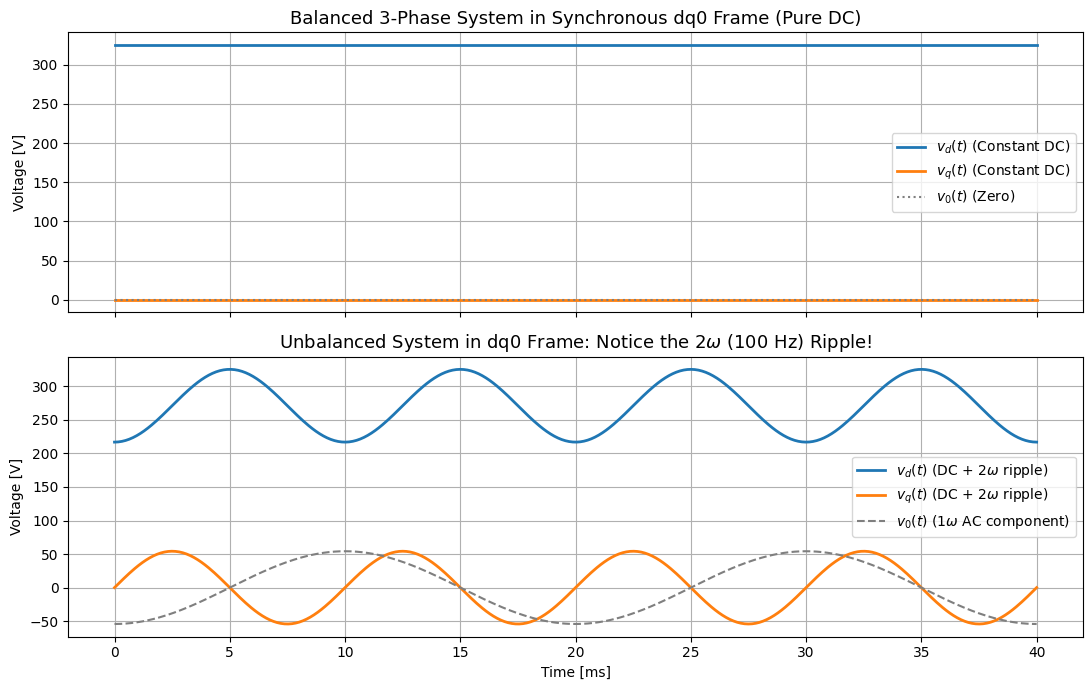

In [7]:
# Synchronous angle theta(t) = w * t
theta = w * t

# 1. Park transform for balanced voltages
vd_bal, vq_bal = tr.park_transform(valpha_bal, vbeta_bal, theta)

# 2. Park transform for unbalanced voltages
vd_unb, vq_unb = tr.park_transform(valpha_unb, vbeta_unb, theta)

# Plot comparing balanced vs unbalanced in dq frame
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# Balanced
axes[0].plot(t * 1000, vd_bal, 'tab:blue', lw=2, label=r'$v_d(t)$ (Constant DC)')
axes[0].plot(t * 1000, vq_bal, 'tab:orange', lw=2, label=r'$v_q(t)$ (Constant DC)')
axes[0].plot(t * 1000, v0_bal, 'tab:gray', linestyle=':', lw=1.5, label=r'$v_0(t)$ (Zero)')
axes[0].set_title("Balanced 3-Phase System in Synchronous dq0 Frame (Pure DC)", fontsize=13)
axes[0].set_ylabel("Voltage [V]")
axes[0].grid(True)
axes[0].legend(loc='right')

# Unbalanced
axes[1].plot(t * 1000, vd_unb, 'tab:blue', lw=2, label=r'$v_d(t)$ (DC + $2\omega$ ripple)')
axes[1].plot(t * 1000, vq_unb, 'tab:orange', lw=2, label=r'$v_q(t)$ (DC + $2\omega$ ripple)')
axes[1].plot(t * 1000, v0_unb, 'tab:gray', linestyle='--', lw=1.5, label=r'$v_0(t)$ ($1\omega$ AC component)')
axes[1].set_title(r"Unbalanced System in dq0 Frame: Notice the $2\omega$ (100 Hz) Ripple!", fontsize=13)
axes[1].set_xlabel("Time [ms]")
axes[1].set_ylabel("Voltage [V]")
axes[1].grid(True)
axes[1].legend(loc='right')

plt.tight_layout()
plt.show()


## 4. Kron Reduction (Network Admittance Reduction)

Kron reduction eliminates interior passive buses (where current injection $\mathbf{I}_L = \mathbf{0}$) using the **Schur complement**:
$$\mathbf{Y}_{\text{Kron}} = \mathbf{Y}_{GG} - \mathbf{Y}_{GL} \mathbf{Y}_{LL}^{-1} \mathbf{Y}_{LG}$$

This reduces the network order while preserving exact electrical multiport behavior between generator buses.


In [8]:
# 3-Bus Power System Example:
# Bus 0: Generator 1
# Bus 1: Generator 2
# Bus 2: Load bus (zero net generation / passive impedance to ground)

z13 = 1j * 0.10  # Line from Bus 0 to 2
z23 = 1j * 0.20  # Line from Bus 1 to 2
y_load = 2.0 - 1j * 1.0  # Passive load admittance at Bus 2

y13 = 1 / z13
y23 = 1 / z23

# Construct 3x3 Y_bus matrix
Y_bus = np.array([
    [ y13,         0,       -y13],
    [   0,       y23,       -y23],
    [-y13,      -y23,  y13 + y23 + y_load]
], dtype=complex)

print("Original 3x3 Y_bus Matrix:")
for row in Y_bus:
    print("  " + "  ".join(f"{val.real:6.2f} + {val.imag:6.2f}j" for val in row))

# Perform Kron reduction to eliminate Bus 2 (Load)
Y_reduced = tr.kron_reduction(Y_bus, kept_buses=[0, 1], eliminated_buses=[2])

print("\nKron-Reduced 2x2 Y_bus Matrix (connecting Gen 1 and Gen 2 directly):")
for row in Y_reduced:
    print("  " + "  ".join(f"{val.real:6.3f} + {val.imag:6.3f}j" for val in row))

# Check reciprocity (symmetry)
assert np.isclose(Y_reduced[0, 1], Y_reduced[1, 0])
print(f"\n✓ Equivalent transfer admittance Y_12 = {Y_reduced[0, 1]:.3f}")


Original 3x3 Y_bus Matrix:
    0.00 + -10.00j    0.00 +   0.00j   -0.00 +  10.00j
    0.00 +   0.00j    0.00 +  -5.00j   -0.00 +   5.00j
   -0.00 +  10.00j   -0.00 +   5.00j    2.00 + -16.00j

Kron-Reduced 2x2 Y_bus Matrix (connecting Gen 1 and Gen 2 directly):
   0.769 + -3.846j   0.385 +  3.077j
   0.385 +  3.077j   0.192 + -3.462j

✓ Equivalent transfer admittance Y_12 = 0.385+3.077j


## 5. Full-Cycle Discrete Fourier Transform (DFT) Phasor Estimation

Digital relays and Phasor Measurement Units (PMUs) sample analog waveforms and estimate the fundamental frequency RMS phasor:
$$\bar{X} = \frac{\sqrt{2}}{N} \sum_{k=0}^{N-1} x[k] e^{-j \frac{2\pi k}{N}}$$

The full-cycle DFT filter completely rejects constant DC offsets and all integer harmonics ($2f_0, 3f_0, 5f_0, \dots$).


Distorted Waveform Phasor Extraction:
  True Fundamental:      RMS = 230.00 V, Phase = +30.00°
  DFT Extracted Phasor:  RMS = 230.00 V, Phase = 30.00°
✓ All integer harmonics and DC offset perfectly rejected by full-cycle DFT!


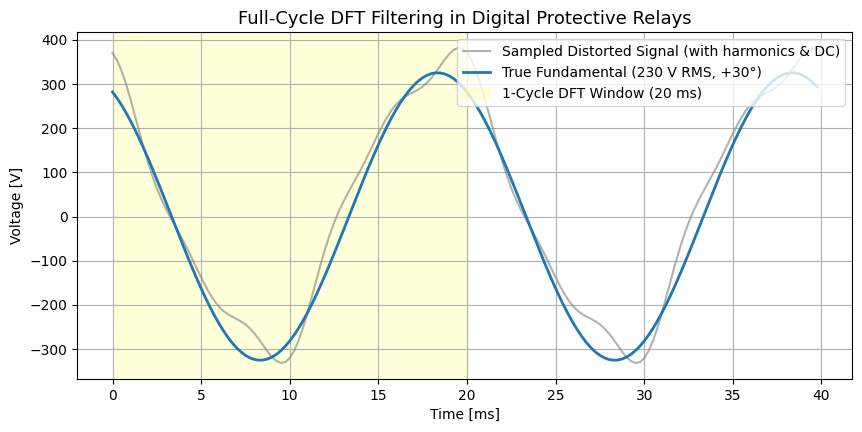

In [9]:
# Sample a distorted 50 Hz voltage waveform:
# Fundamental (230 V RMS, +30 deg phase) + DC offset + 3rd harmonic + 5th harmonic
fs = 4000.0  # Sampling frequency: 4000 Hz (80 samples/cycle)
t_samples = np.linspace(0, 0.04, int(fs * 0.04), endpoint=False)

v_fundamental = 230.0 * np.sqrt(2) * np.cos(2 * np.pi * 50 * t_samples + np.deg2rad(30.0))
v_dc_offset = 25.0
v_3rd = 30.0 * np.sqrt(2) * np.cos(2 * np.pi * 150 * t_samples)
v_5th = 15.0 * np.sqrt(2) * np.cos(2 * np.pi * 250 * t_samples)

v_distorted = v_fundamental + v_dc_offset + v_3rd + v_5th

# Estimate phasor using one full cycle (first 80 samples)
X_estimated = tr.dft_phasor_estimation(v_distorted, sampling_rate=fs, nominal_freq=50.0)

print("Distorted Waveform Phasor Extraction:")
print("  True Fundamental:      RMS = 230.00 V, Phase = +30.00°")
print(f"  DFT Extracted Phasor:  RMS = {abs(X_estimated):.2f} V, Phase = {np.rad2deg(np.angle(X_estimated)):.2f}°")

assert np.isclose(abs(X_estimated), 230.0, atol=1e-2)
assert np.isclose(np.rad2deg(np.angle(X_estimated)), 30.0, atol=1e-2)
print("✓ All integer harmonics and DC offset perfectly rejected by full-cycle DFT!")

# Plot the waveform and extracted phasor
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(t_samples * 1000, v_distorted, 'tab:gray', alpha=0.6, label='Sampled Distorted Signal (with harmonics & DC)')
ax.plot(t_samples * 1000, v_fundamental, 'tab:blue', lw=2, label='True Fundamental (230 V RMS, +30°)')
ax.axvspan(0, 20, color='yellow', alpha=0.15, label='1-Cycle DFT Window (20 ms)')
ax.set_title("Full-Cycle DFT Filtering in Digital Protective Relays", fontsize=13)
ax.set_xlabel("Time [ms]")
ax.set_ylabel("Voltage [V]")
ax.grid(True)
ax.legend(loc='upper right')
plt.show()
